# Implied volatility surface & volatility calculation

This notebook demonstrates a selection of capabilities of the **Volaris** library through:
- finding the implied volatility smile and surface via Black-Scholes model inversion
- volatility calculation: Close-to-Close, Parkinson, Garman-Klass, Yang-Zhang estimators
- comparison of estimator efficiency on simulated OHLC data

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from volaris import (
    bs_price, 
    hist_vol_close_to_close, hist_vol_parkinson, hist_vol_garman_klass, hist_vol_yang_zhang,
    gbm_paths,
    implied_vol,
)

S, r, sigma = 100.0, 0.05, 0.20
rng = np.random.default_rng(42)

---

## Implied volatility smile

In the Black-Scholes world, IV should be flat across all strikes.

In practice markets show a **volatility smile**: OTM puts and calls trade at higher IV than ATM.

| Term | Full name | Condition (call) | Condition (put) |
|------|-----------|-----------------|-----------------|
| ATM | at-the-money | K = S | K = S |
| OTM | out-of-the-money | K > S | K < S |
| ITM | in-the-money | K < S | K > S |

We simulate a smile by pricing options with a strike-dependent volatility, then recovering implied volatility from those prices using Newton-Raphson / bisection inversion.

In [2]:
T = 1.0
strikes = np.linspace(50, 250, 50)

def smile_sigma(K):
    m = (K - S) / S
    return 0.20 - 0.05 * m + 0.10 * m**2

market_prices = np.array([bs_price(S, K, T, r, smile_sigma(K), 1) for K in strikes])
ivs = np.array([implied_vol(p, S, K, T, r, 1) for p, K in zip(market_prices, strikes)])
true_sigmas = np.array([smile_sigma(K) for K in strikes])

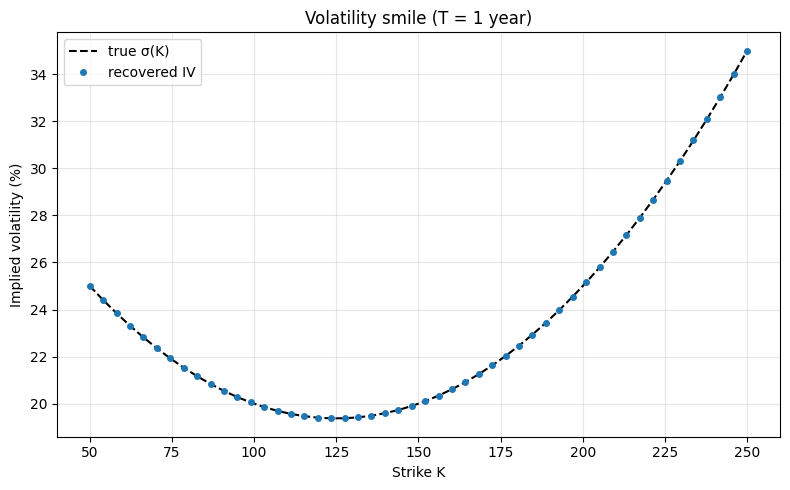

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(strikes, true_sigmas * 100, "k--", label="true σ(K)")
plt.plot(strikes, ivs * 100, "o", ms=4, label="recovered IV")
plt.xlabel("Strike K")
plt.ylabel("Implied volatility (%)")
plt.title("Volatility smile (T = 1 year)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## Volatility surface

Extending the smile across multiple maturities gives a **volatility surface**.

The term structure of volatility reflects market expectations at different horizons.

In [4]:
tenors  = np.array([0.1, 0.25, 0.5, 1.0, 1.5, 2.0])
strikes_grid = np.linspace(75, 125, 30)

surface = np.zeros((len(tenors), len(strikes_grid)))

for i, T_ in enumerate(tenors):
    for j, K in enumerate(strikes_grid):
        m = (K - S) / S
        vol = 0.20 - 0.05 * m + 0.10 * m**2 + 0.02 * np.sqrt(T_)
        price = bs_price(S, K, T_, r, vol, 1 if K >= S else 0)
        surface[i, j] = implied_vol(price, S, K, T_, r, 1 if K >= S else 0)

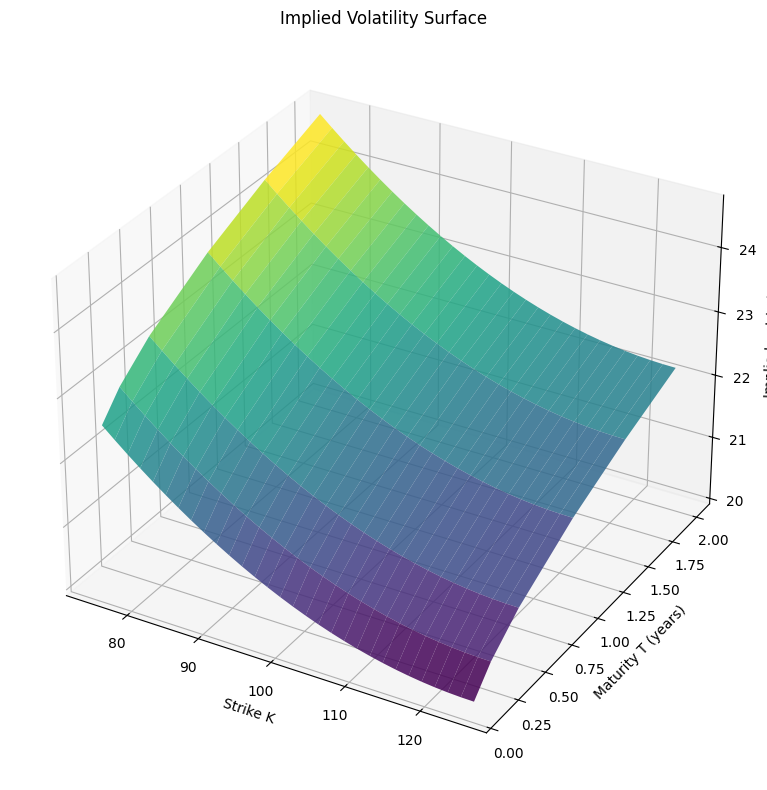

In [5]:
KK, TT = np.meshgrid(strikes_grid, tenors)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(KK, TT, surface * 100, cmap="viridis", alpha=0.85)
ax.set_xlabel("Strike K"); 
ax.set_ylabel("Maturity T (years)")
ax.set_zlabel("Implied vol (%)")
ax.set_title("Implied Volatility Surface")
plt.tight_layout()
plt.show()

---

## Historical volatility estimators

Volaris implements four classical estimators of realised volatility, all computed in C from OHLC (Open, High, Low, Close) price data.

| Estimator | Uses |
|-----------|------|
| Close-to-Close | log returns | 
| Parkinson | High, Low |
| Garman-Klass | Open, High, Low, Close |
| Yang-Zhang | Open, High, Low, Close |

We simulate 252 days of OHLC data from GBM with known sigma = 20%.

In [6]:
true_sigma = 0.20
N_days = 252

# Simulate intraday paths (open, high, low, close per day)

intraday_steps = 100
paths = gbm_paths(S0=100.0, mu=0.05, sigma=true_sigma, T=1.0, N_steps=N_days * intraday_steps, N_paths=1)
prices = paths[0]
days = prices.reshape(N_days, intraday_steps)
open_ = days[:, 0].copy()
close_ = days[:, -1].copy()
high_ = days.max(axis=1)
low_ = days.min(axis=1)

returns = np.diff(np.log(close_))
returns = np.ascontiguousarray(returns)
open_ = np.ascontiguousarray(open_[1:])
close_ = np.ascontiguousarray(close_[1:])
high_ = np.ascontiguousarray(high_[1:])
low_ = np.ascontiguousarray(low_[1:])

In [7]:
ctc = hist_vol_close_to_close(returns)
park = hist_vol_parkinson(high_, low_)
gk = hist_vol_garman_klass(high_, low_, open_, close_)
yz = hist_vol_yang_zhang(high_, low_, open_, close_)

print(f"True sigma:     {true_sigma:.4f}")
print("---------------")
print(f"Close-to-Close: {ctc:.4f}")
print(f"Parkinson:      {park:.4f}")
print(f"Garman-Klass:   {gk:.4f}")
print(f"Yang-Zhang:     {yz:.4f}")

True sigma:     0.2000
---------------
Close-to-Close: 0.1970
Parkinson:      0.1866
Garman-Klass:   0.1831
Yang-Zhang:     0.1871


---

## Rolling historical volatility

Computing volatility over a rolling 21-day window shows how each estimator tracks changing market conditions over time.

In [8]:
window = 21
n = len(returns)

ctc_roll, park_roll, gk_roll, yz_roll = [], [], [], []

for start in range(n - window):
    sl = slice(start, start + window)
    ctc_roll.append(hist_vol_close_to_close(np.ascontiguousarray(returns[sl])))
    park_roll.append(hist_vol_parkinson(np.ascontiguousarray(high_[sl]), np.ascontiguousarray(low_[sl])))
    gk_roll.append(hist_vol_garman_klass(np.ascontiguousarray(high_[sl]), np.ascontiguousarray(low_[sl]), 
                                         np.ascontiguousarray(open_[sl]), np.ascontiguousarray(close_[sl])))
    yz_roll.append(hist_vol_yang_zhang(np.ascontiguousarray(high_[sl]), np.ascontiguousarray(low_[sl]),
                                       np.ascontiguousarray(open_[sl]), np.ascontiguousarray(close_[sl])))

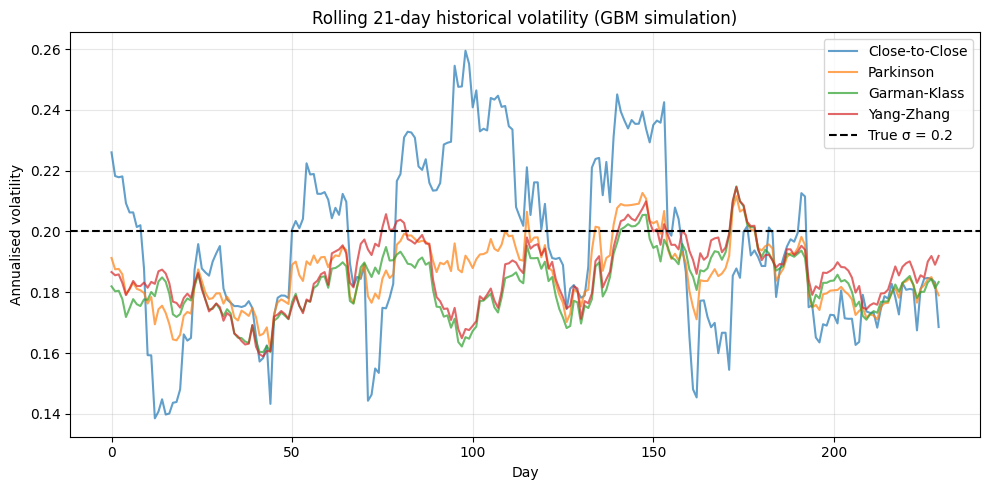

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(ctc_roll, label="Close-to-Close", alpha=0.7)
plt.plot(park_roll, label="Parkinson", alpha=0.7)
plt.plot(gk_roll, label="Garman-Klass", alpha=0.7)
plt.plot(yz_roll, label="Yang-Zhang", alpha=0.7)
plt.axhline(true_sigma, color="black", ls="--", label=f"True σ = {true_sigma}")
plt.xlabel("Day"); plt.ylabel("Annualised volatility")
plt.title("Rolling 21-day historical volatility (GBM simulation)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()